In [1]:
import pandas as pd

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [8]:
import seaborn as sns
sns.set(style='whitegrid')

In [9]:
df=pd.read_csv('anaconda_projects/169216c7-f7e0-4914-bb1a-6b413b063a32/Amazon (1).csv')

In [12]:
df.shape

(100000, 20)

In [13]:
df.head(5)

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [14]:
df['OrderDate']=pd.to_datetime(df['OrderDate'],errors='coerce')

In [15]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [16]:
missing_values= df.isnull().sum()

In [17]:
missing_values

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

In [19]:
numeric_df=df.select_dtypes(include=[np.number])

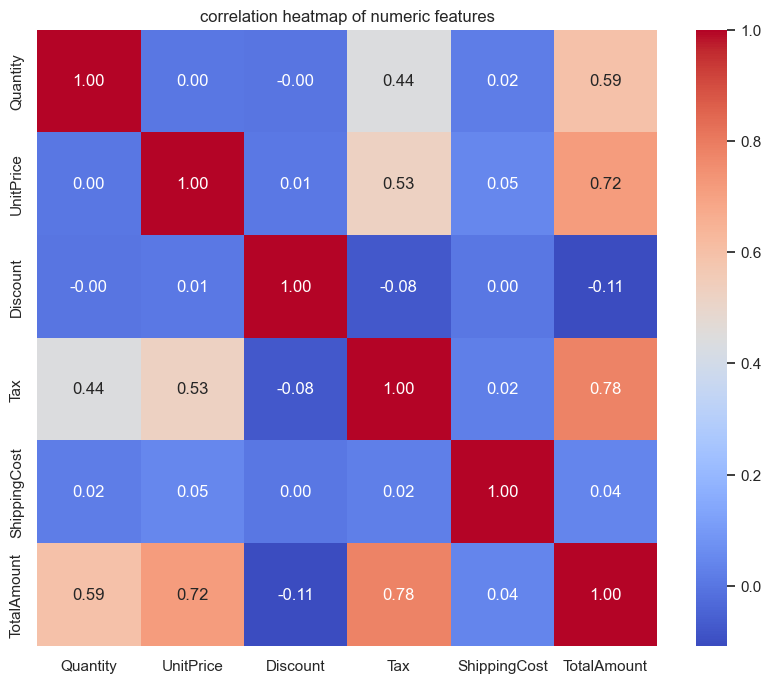

In [21]:
if numeric_df.shape[1]>=4:
    plt.figure(figsize=(10,8))
    corr_Matrix=numeric_df.corr()
    sns.heatmap(corr_Matrix,annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('correlation heatmap of numeric features')
    plt.show()
else:
    print('not enough columns for correlation heatmap')

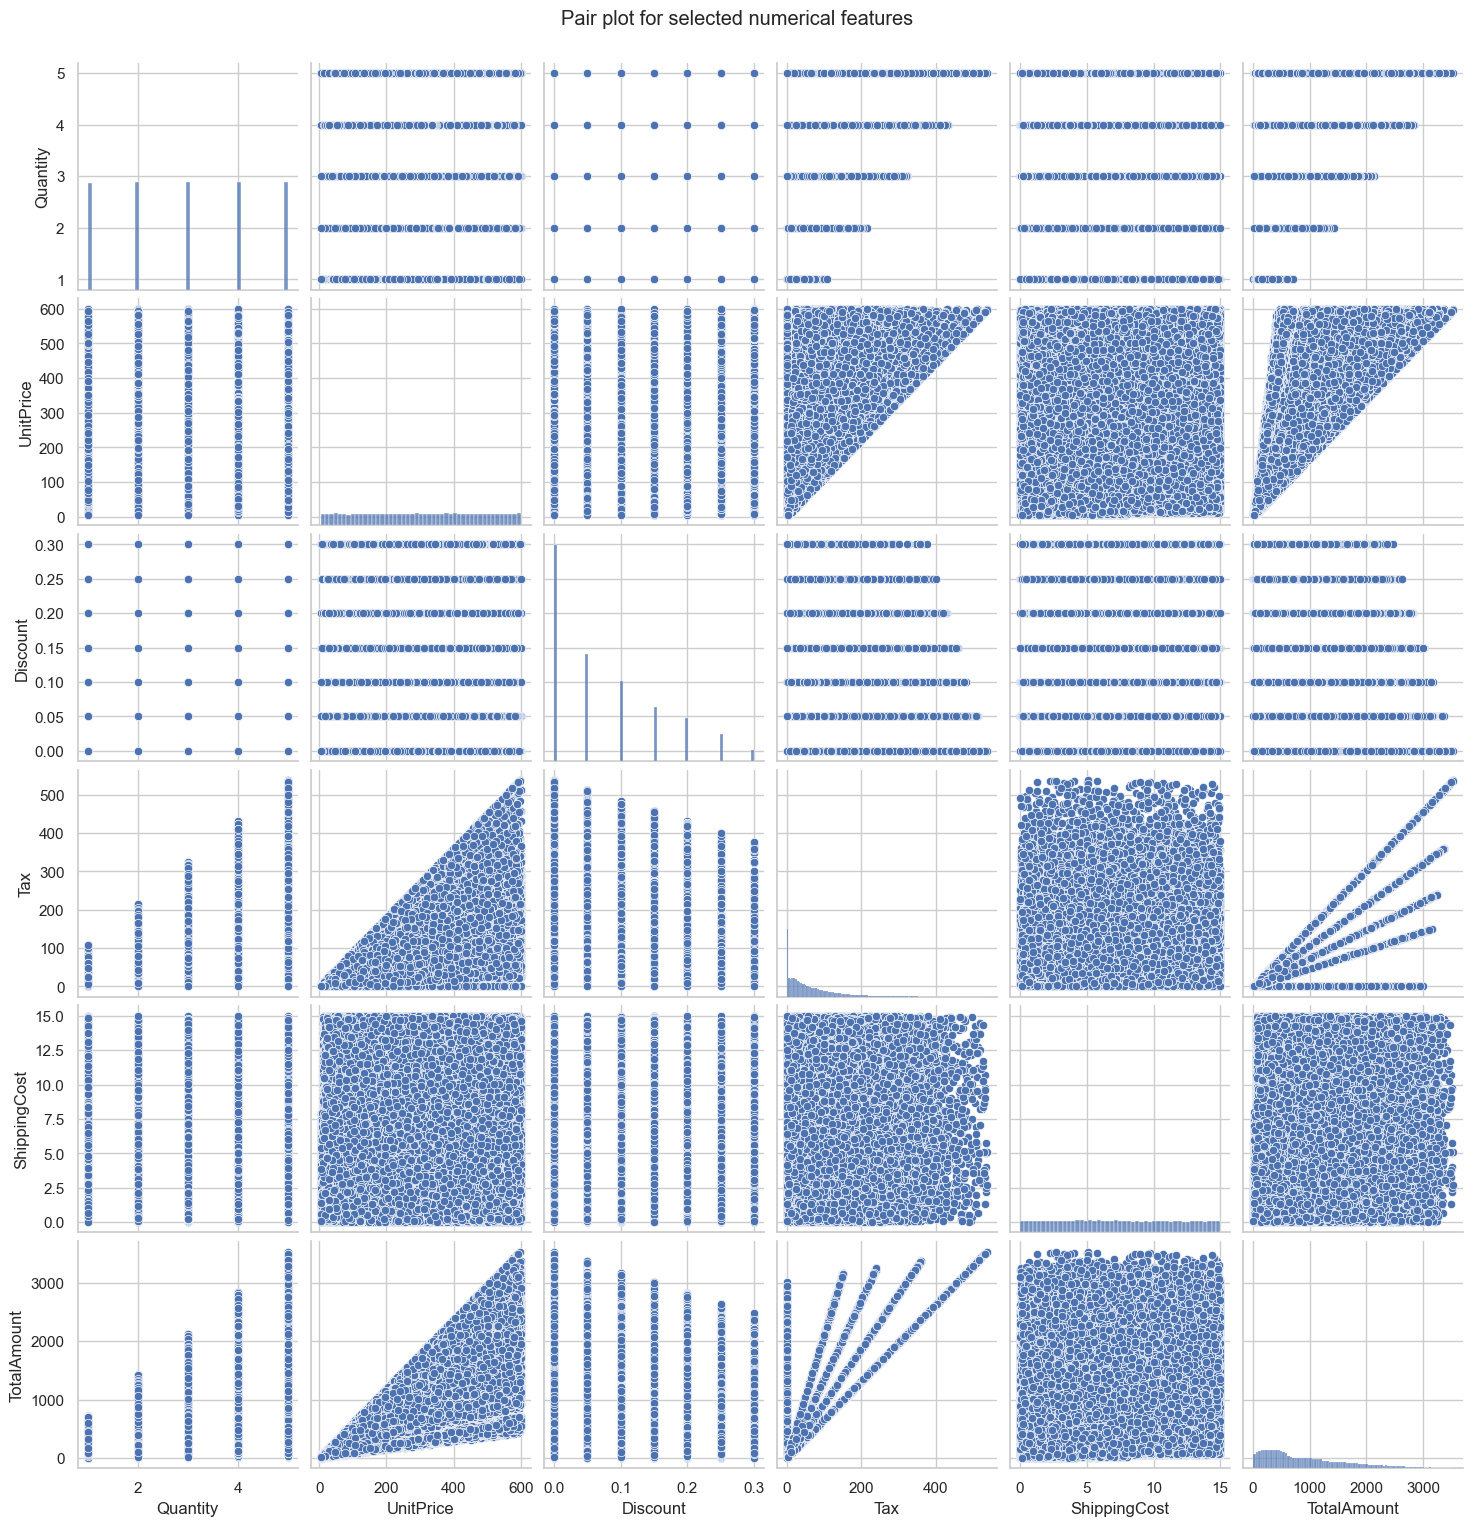

In [25]:
pairplot_cols=['Quantity','UnitPrice','Discount','Tax','ShippingCost','TotalAmount']
if set(pairplot_cols).issubset(df.columns):
    sns.pairplot(df[pairplot_cols].dropna())
    plt.suptitle('Pair plot for selected numerical features', y=1.02)
    plt.show()
else:
    print('some of the required columns for pair plor are missing')

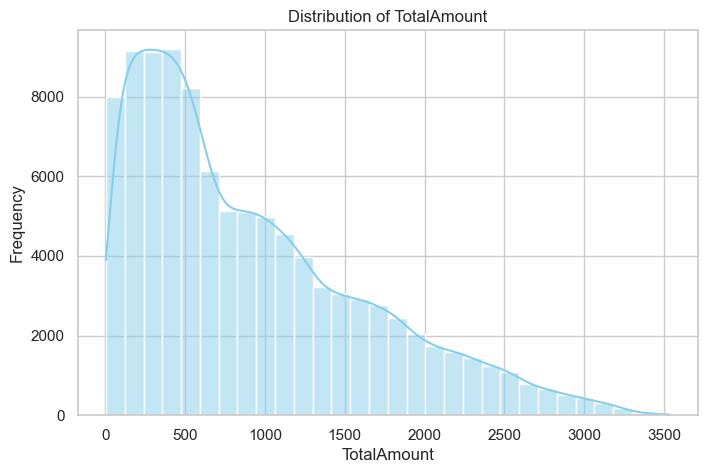

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalAmount'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of TotalAmount')
plt.xlabel('TotalAmount')
plt.ylabel('Frequency')
plt.show()

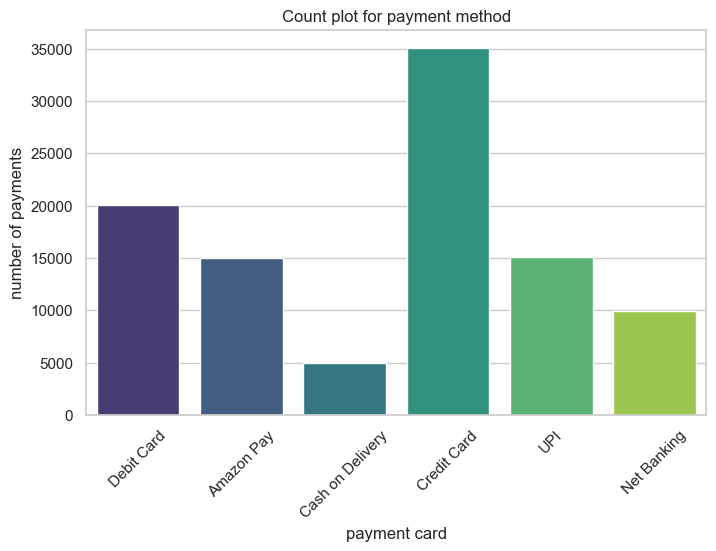

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='PaymentMethod',palette='viridis')
plt.title('Count plot for payment method')
plt.xlabel('payment card')
plt.ylabel('number of payments')
plt.xticks(rotation=45)
plt.show()

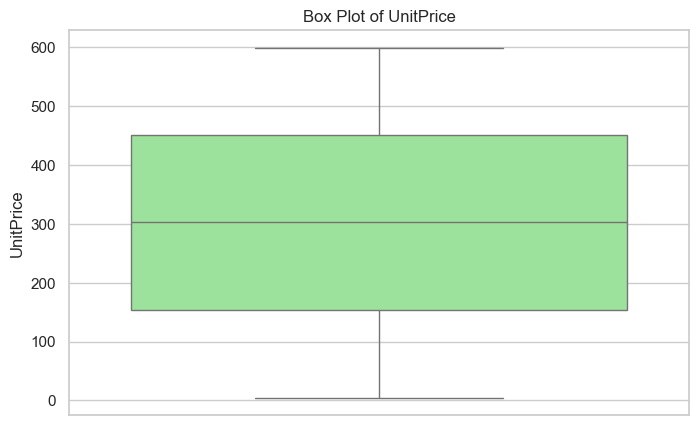

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y='UnitPrice', color='lightgreen')
plt.title('Box Plot of UnitPrice')
plt.ylabel('UnitPrice')
plt.show()

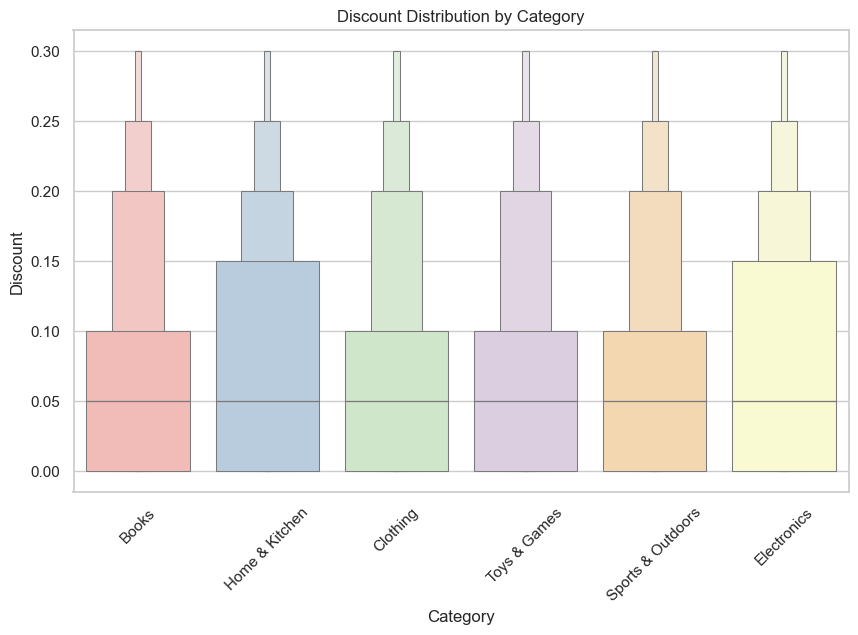

In [35]:
# Boxen plot to visualize the Discount across different Categories
plt.figure(figsize=(10, 6))
sns.boxenplot(data=df, x='Category', y='Discount', palette='Pastel1')
plt.title('Discount Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Discount')
plt.xticks(rotation=45)
plt.show()

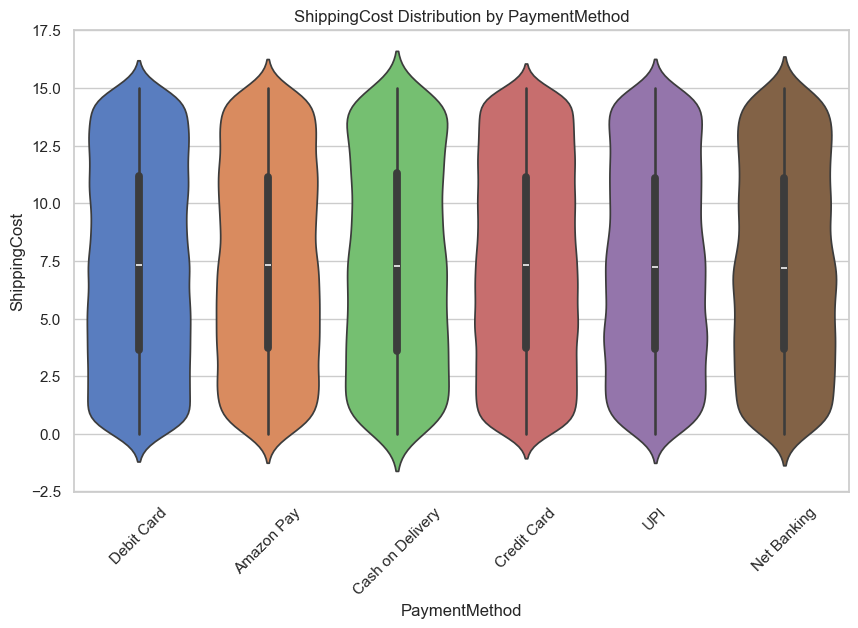

In [36]:
# Violin plot to compare ShippingCost distribution among Payment Methods
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='PaymentMethod', y='ShippingCost', palette='muted')
plt.title('ShippingCost Distribution by PaymentMethod')
plt.xlabel('PaymentMethod')
plt.ylabel('ShippingCost')
plt.xticks(rotation=45)
plt.show()


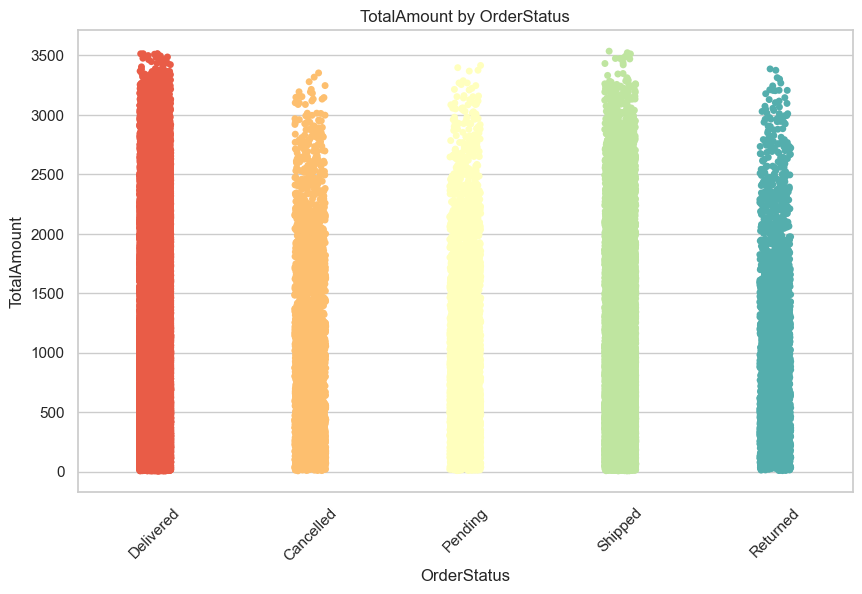

In [37]:
# Strip plot to show TotalAmount variation across different OrderStatus values
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='OrderStatus', y='TotalAmount', jitter=True, palette='Spectral')
plt.title('TotalAmount by OrderStatus')
plt.xlabel('OrderStatus')
plt.ylabel('TotalAmount')
plt.xticks(rotation=45)
plt.show()


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
feature_cols=['Quantity','UnitPrice','Discount','Tax','ShippingCost']
targeting_col='TotalAmount'
model_df=df[feature_cols+[targeting_col]].dropna()
X=model_df[feature_cols]
Y=model_df[targeting_col]
X_train,X_test, Y_train,Y_test= train_test_split(X,Y, test_size=0.2,random_state=42)

# Initialize and train the linear regression model
lr=LinearRegression()
lr.fit(X_train,Y_train)
y_predict=lr.predict(X_test)
r2=r2_score(Y_test, y_predict)
print('R2 score on the test set:', r2)

R2 score on the test set: 0.9095060550803167
